# Price Elasticity Model
- Justin Wall, Data Scientist, Kettlerock Brewing Co.

## Data Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/kettlerock_sales_1.csv', parse_dates=['week'])

In [2]:
import numpy as np
rng = np.random.default_rng(42)

HAWK_PREMIUMS = {'IPA': 1.05, 'Lager': 1.03, 'Stout': 1.08}
HAWK_REF_SKUS = {
    'IPA':   ['SKU001', 'SKU002', 'SKU003', 'SKU005'],
    'Lager': ['SKU010', 'SKU011'],
    'Stout': ['SKU006', 'SKU007'],
}

for cat, premium in HAWK_PREMIUMS.items():
    # Year-round SKUs only — removes seasonal entry/exit noise
    yr_avg = df[df['sku_id'].isin(HAWK_REF_SKUS[cat])].groupby('week')['price'].mean()
    hawk_mean = yr_avg.mean() * premium
    kr_dev = yr_avg - yr_avg.mean()
    hawk = hawk_mean + 0.85 * kr_dev + rng.normal(0, 0.005 * hawk_mean, size=len(yr_avg))
    week_to_hawk = dict(zip(yr_avg.index, hawk.round(2)))
    df.loc[df['category'] == cat, 'hawkstone_price'] = df.loc[df['category'] == cat, 'week'].map(week_to_hawk)

for cat in HAWK_PREMIUMS:
    sub = df[df['category']==cat].groupby('week').agg(kr=('price','mean'), hawk=('hawkstone_price','first'))
    r = sub['kr'].corr(sub['hawk'])
    n = len(sub)
    print(f"  {cat:8s}  r = {r:.3f}  F = {r**2*(n-2)/(1-r**2):.1f}")

  IPA       r = 0.771  F = 149.2
  Lager     r = 0.618  F = 63.1
  Stout     r = 0.860  F = 290.1


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4848, 16)
week                   datetime64[us]
year                            int64
week_of_year                    int64
season                            str
region                            str
sku_id                            str
sku_name                          str
category                          str
pack_size                         str
is_seasonal_release              bool
price                         float64
is_promo                         bool
promo_event                       str
hawkstone_price               float64
units_sold                      int64
revenue                       float64
dtype: object
week                      0
year                      0
week_of_year              0
season                    0
region                    0
sku_id                    0
sku_name                  0
category                  0
pack_size                 0
is_seasonal_release       0
price                     0
is_promo                  0
promo_event            4638
haw

In [4]:
print(df[['price','units_sold','revenue']].describe().round(2))
print(df['region'].value_counts())
print(df['category'].value_counts())
print(df['week'].min(), df['week'].max())

         price  units_sold  revenue
count  4848.00     4848.00  4848.00
mean     15.16      136.01  2082.56
std       4.39       66.19  1268.41
min       9.22       14.00   296.10
25%      11.49       85.00  1130.75
50%      13.49      126.00  1785.43
75%      18.84      177.00  2671.39
max      27.21      460.00  8192.60
region
Twin Cities      1616
Chicago          1616
Upper Midwest    1616
Name: count, dtype: int64
category
IPA      1362
Stout     852
Lager     816
Sour      678
Mixed     312
Amber     312
THC       300
Wheat     216
Name: count, dtype: int64
2022-01-03 00:00:00 2023-12-25 00:00:00


***
### **Notes**:
- 3 Regions
- 8 categories
- price, units sold, revenue
***

## Data Alignment - Business

Before modeling, we verify the data matches Kettlerock's operational reality across pricing, volume, and key known events.

### Part 1 -> Portfolio Summary
What you're looking for: SKU010 Kettlerock Lager should show price_min == price_max == 9.99. Seasonal releases should show weeks_in_market < 104. Promo weeks should be non-zero for IPA/Lager/Stout/Sour categories.

In [5]:
summary = (
    df.groupby(['sku_id', 'sku_name', 'category', 'pack_size', 'is_seasonal_release'])
    .agg(
        weeks_in_market  = ('week',       'nunique'),
        avg_price        = ('price',       'mean'),
        price_min        = ('price',       'min'),
        price_max        = ('price',       'max'),
        avg_weekly_units = ('units_sold',  'mean'),
        avg_weekly_rev   = ('revenue',     'mean'),
        promo_weeks      = ('is_promo',    'sum'),
    )
    .round(2)
    .reset_index()
)
summary

,sku_id,sku_name,category,pack_size,is_seasonal_release,weeks_in_market,avg_price,price_min,price_max,avg_weekly_units,avg_weekly_rev,promo_weeks
0,SKU001,Irongate IPA,IPA,6-pack,False,104,12.09,10.41,13.33,126.04,1522.81,18
1,SKU002,Irongate IPA,IPA,12-pack,False,104,22.40,19.22,24.20,164.80,3678.80,18
2,SKU003,Copperhead Hazy IPA,IPA,6-pack,False,104,13.68,11.97,14.80,124.12,1697.25,18
3,SKU004,Trailblazer Session IPA,IPA,6-pack,True,38,11.21,9.37,12.33,179.05,2003.85,18
4,SKU005,Double Irongate DIPA,IPA,4-pack,False,104,16.22,13.64,17.84,56.18,911.17,18
5,SKU006,Summit Stout,Stout,6-pack,False,104,11.56,9.78,12.57,124.01,1428.25,12
6,SKU007,Summit Stout,Stout,12-pack,False,104,21.43,18.47,23.14,163.79,3504.44,12
7,SKU008,Midnight Porter,Stout,6-pack,True,38,11.16,9.57,12.20,174.25,1954.46,6
8,SKU009,Barrel-Aged Summit,Stout,4-pack,True,38,20.27,18.39,21.63,80.24,1624.24,6
9,SKU010,Kettlerock Lager,Lager,6-pack,False,104,10.19,9.99,10.39,123.35,1260.27,0


### Part 2 -> Price over time with promo flags and Hawkstone overlay
Do this for one SKU at a time. Irongate IPA 6-pack (SKU001) is the right one to lead with since it's the one Mara mentioned. Repeat for Kettlerock Lager and Summit Stout. Those three cover the categories where you have Hawkstone data and tell the most complete pricing story.

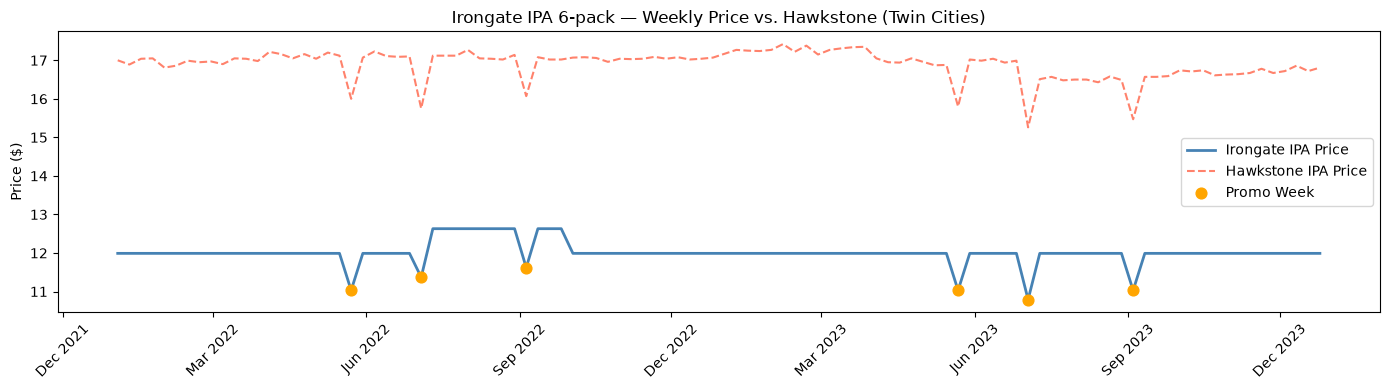

In [6]:
sku    = 'SKU001'
region = 'Twin Cities'

sku_df  = df[(df.sku_id == sku) & (df.region == region)].copy()
promos  = sku_df[sku_df.is_promo]
hawk_df = sku_df[sku_df.hawkstone_price.notna()]

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(sku_df.week, sku_df.price, label='Irongate IPA Price', color='steelblue', linewidth=2)
ax.plot(hawk_df.week, hawk_df.hawkstone_price, label='Hawkstone IPA Price',
        color='tomato', linewidth=1.5, linestyle='--', alpha=0.8)
ax.scatter(promos.week, promos.price, color='orange', zorder=5,
           label='Promo Week', s=60)

ax.set_title('Irongate IPA 6-pack — Weekly Price vs. Hawkstone (Twin Cities)')
ax.set_ylabel('Price ($)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Part 3 -> Volume over time by region
Stack all three regions on one chart for the flagship SKU. Shows both the seasonal pattern and the regional volume differences Mara cares about for the distributor negotiation.

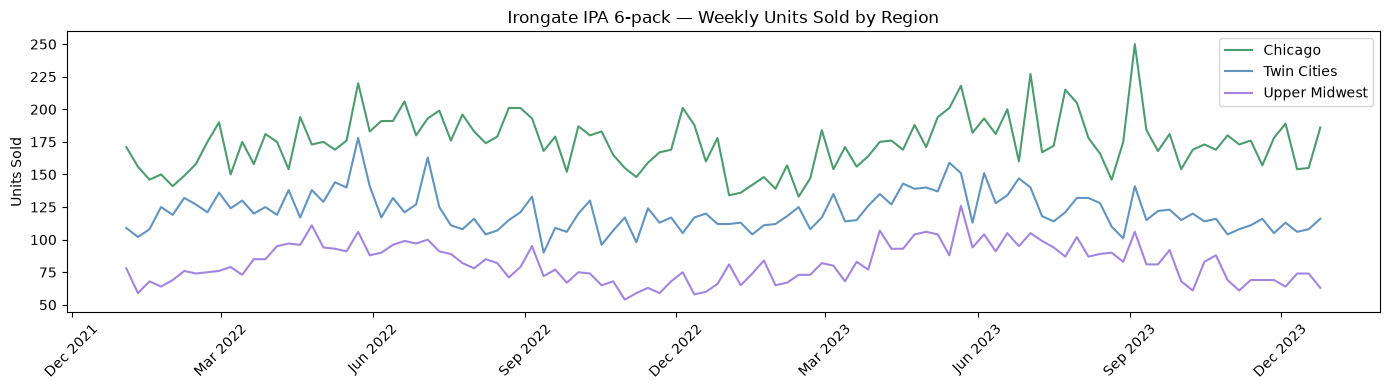

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))

colors = {'Twin Cities': 'steelblue', 'Chicago': 'seagreen', 'Upper Midwest': 'mediumpurple'}

for region, grp in df[df.sku_id == 'SKU001'].groupby('region'):
    ax.plot(grp.week, grp.units_sold, label=region,
            color=colors[region], linewidth=1.5, alpha=0.85)

ax.set_title('Irongate IPA 6-pack — Weekly Units Sold by Region')
ax.set_ylabel('Units Sold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Part 4 -> Answer to Mara's specific question
This is the most important part of alignment. She mentioned a $1.50 price bump on Irongate IPA in spring 2022. Find the actual event in the data first. Scan for the price change event around weeks 10-20 of 2022. Once you spot it, isolate a window around it. Then answer the 3 questions in the email.

In [8]:
sku_tc = df[(df.sku_id == 'SKU001') & (df.region == 'Twin Cities')].copy()
sku_tc[['week','price','units_sold','revenue','is_promo']].head(35)

,week,price,units_sold,revenue,is_promo
0,2022-01-03,11.99,109,1306.91,False
1,2022-01-10,11.99,102,1222.98,False
2,2022-01-17,11.99,108,1294.92,False
3,2022-01-24,11.99,125,1498.75,False
4,2022-01-31,11.99,119,1426.81,False
5,2022-02-07,11.99,132,1582.68,False
6,2022-02-14,11.99,127,1522.73,False
7,2022-02-21,11.99,121,1450.79,False
8,2022-02-28,11.99,136,1630.64,False
9,2022-03-07,11.99,124,1486.76,False


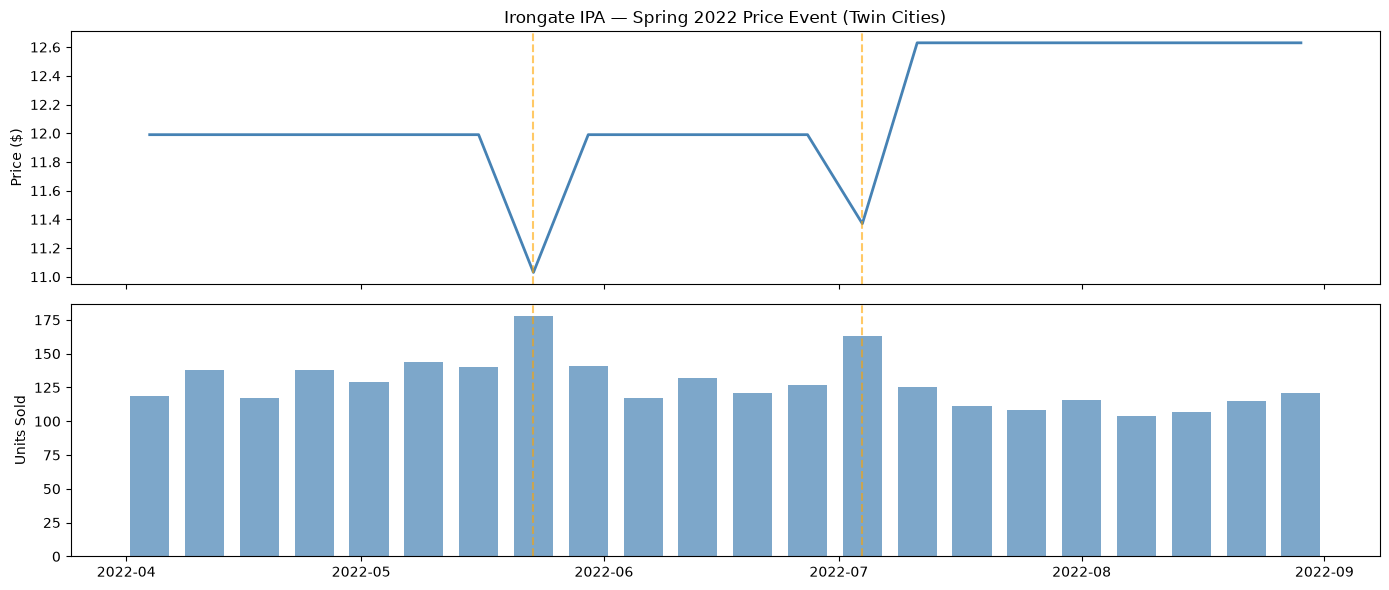

In [9]:
window = sku_tc[(sku_tc.week >= '2022-04-04') & (sku_tc.week <= '2022-08-29')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(window.week, window.price, color='steelblue', linewidth=2)
ax1.set_ylabel('Price ($)')
ax1.set_title("Irongate IPA — Spring 2022 Price Event (Twin Cities)")

ax2.bar(window.week, window.units_sold, color='steelblue', alpha=0.7, width=5)
ax2.set_ylabel('Units Sold')

# flag promos
for _, row in window[window.is_promo].iterrows():
    ax1.axvline(row.week, color='orange', linestyle='--', alpha=0.6)
    ax2.axvline(row.week, color='orange', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [10]:
# Quick revenue math around the price change
before = window[window.week < '2022-07-11']
after  = window[window.week >= '2022-07-11']

print(f"Avg weekly units before: {before.units_sold.mean():.0f}")
print(f"Avg weekly units after:  {after.units_sold.mean():.0f}")
print(f"Avg weekly revenue before: ${before.revenue.mean():.0f}")
print(f"Avg weekly revenue after:  ${after.revenue.mean():.0f}")

# Did lager pick up? Cross-SKU substitution check
lager_tc = df[(df.sku_id == 'SKU010') & (df.region == 'Twin Cities')]
lager_window = lager_tc[(lager_tc.week >= '2022-04-04') & (lager_tc.week <= '2022-08-29')]
print(f"\nLager avg units before: {lager_window[lager_window.week < '2022-07-11'].units_sold.mean():.0f}")
print(f"Lager avg units after:  {lager_window[lager_window.week >= '2022-07-11'].units_sold.mean():.0f}")

Avg weekly units before: 136
Avg weekly units after:  113
Avg weekly revenue before: $1611
Avg weekly revenue after:  $1432

Lager avg units before: 128
Lager avg units after:  125


### Part 5 -> NEW Question! -> Two products going in very different directions
This is the most important part of alignment. She mentioned a $1.50 price bump on Irongate IPA in spring 2022. Find the actual event in the data first. Scan for the price change event around weeks 10-20 of 2022. Once you spot it, isolate a window around it. Then answer the 3 questions in the email.

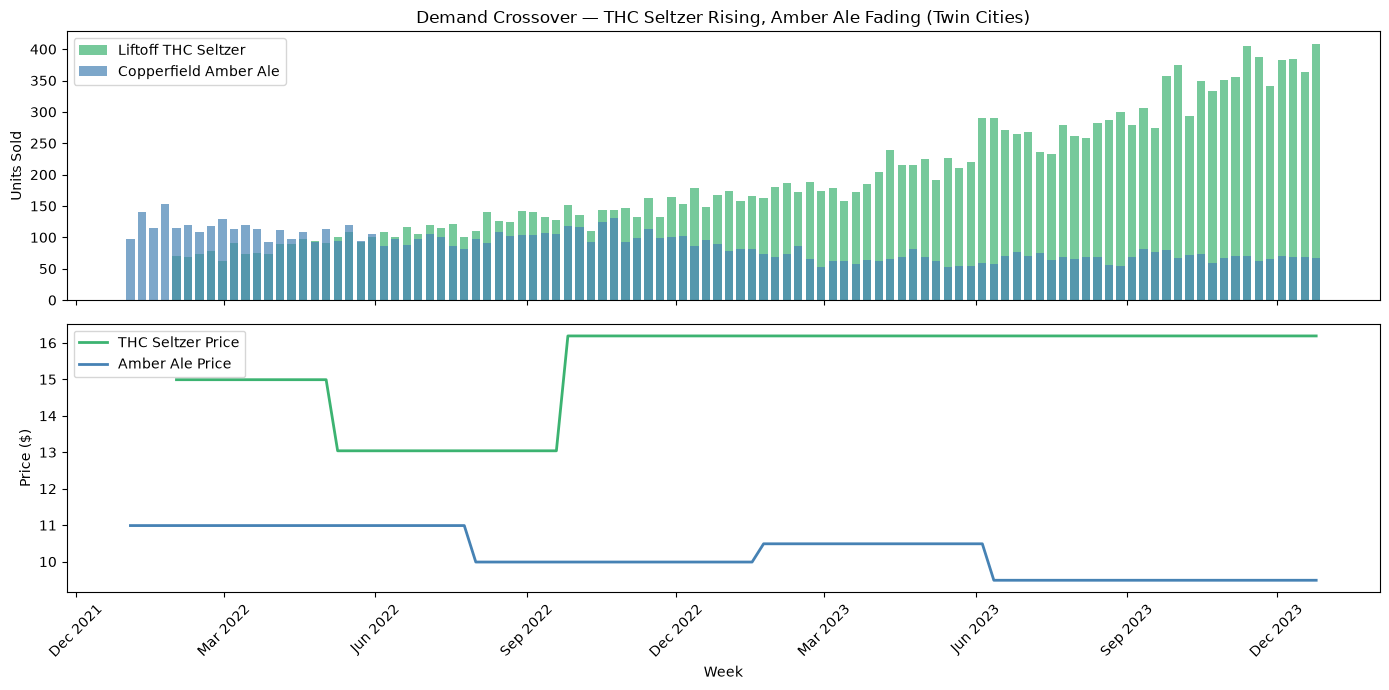

In [11]:
# Mara's question: "Are we seeing what I think we're seeing on these two products?"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

thc = df[(df.sku_id == 'SKU021') & (df.region == 'Twin Cities')]
amb = df[(df.sku_id == 'SKU022') & (df.region == 'Twin Cities')]

# ── Top panel: units (bars) ───────────────────────────────────────────────────
ax1.bar(thc['week'], thc['units_sold'], width=5,
        color='mediumseagreen', alpha=0.7, label='Liftoff THC Seltzer')
ax1.bar(amb['week'], amb['units_sold'], width=5,
        color='steelblue', alpha=0.7, label='Copperfield Amber Ale')
ax1.set_ylabel('Units Sold')
ax1.set_title("Demand Crossover — THC Seltzer Rising, Amber Ale Fading (Twin Cities)")
ax1.legend()

# ── Bottom panel: price (lines) ───────────────────────────────────────────────
ax2.plot(thc['week'], thc['price'], color='mediumseagreen',
         linewidth=2, label='THC Seltzer Price')
ax2.plot(amb['week'], amb['price'], color='steelblue',
         linewidth=2, label='Amber Ale Price')
ax2.set_ylabel('Price ($)')
ax2.set_xlabel('Week')
ax2.legend()
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

***
### **Notes**:
1. The full portfolio summary - what do we have, when do we have it, how much does it cost, how much does it earn. The most revenue comes from the irongate ipa, but the most units come from the seasonal pumpkin ipa.
2. Hawkstone is our competitor, and we can see their price over time in the twin cities market. We chose our Irongate IPA and can visually see our pricing promotions over time in comparison with Hawkstone prices.
3. For the Irongate IPA, we can see sales follows similar trends across our 3 distribution centers, but chicago sells the most, followed by the twin cities, followed by the upper midwest.
4. There does appear to be a price pump of $1.50 on the week of 7/11/2022 for Irongate IPA, though Mara said it was spring. It was preceeded by a promo. We can see the comparison between price & units, and that as the product was put on promotion, the demand increased; and even as the price jumped after the promo, the demand decreased to below previous non-promo demand. So yes, the price increase dropped units sold for Irongate IPA. Average weekly units dropped by 23 (17%), but price only dropped by $179/week (11%). There were a few promotions before the price drop which make units seem more dramatic than sales. We checked out whether SKU10 the 6-pack Kettlerock Lager picked up some of the slack after the IPA lost units, but it does not appear so.
5. Demand for these two products are going in two very different directions - THC to the moon, Amber to the basement. Prices at various levels have been tested. 
***

## Exploratory Data Analysis

In [12]:
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

### Part 1 -> Price variation per SKU (identification check)
Before anything else, can you even estimate elasticity for a given SKU? If price barely moves, the answer is no. Plot price std dev and unique price count per SKU. SKU010 will be the obvious call-out — flat line, nothing to work with. This directly motivates partial pooling in the hierarchical model: sparse/low-variation SKUs need to borrow strength from their category.

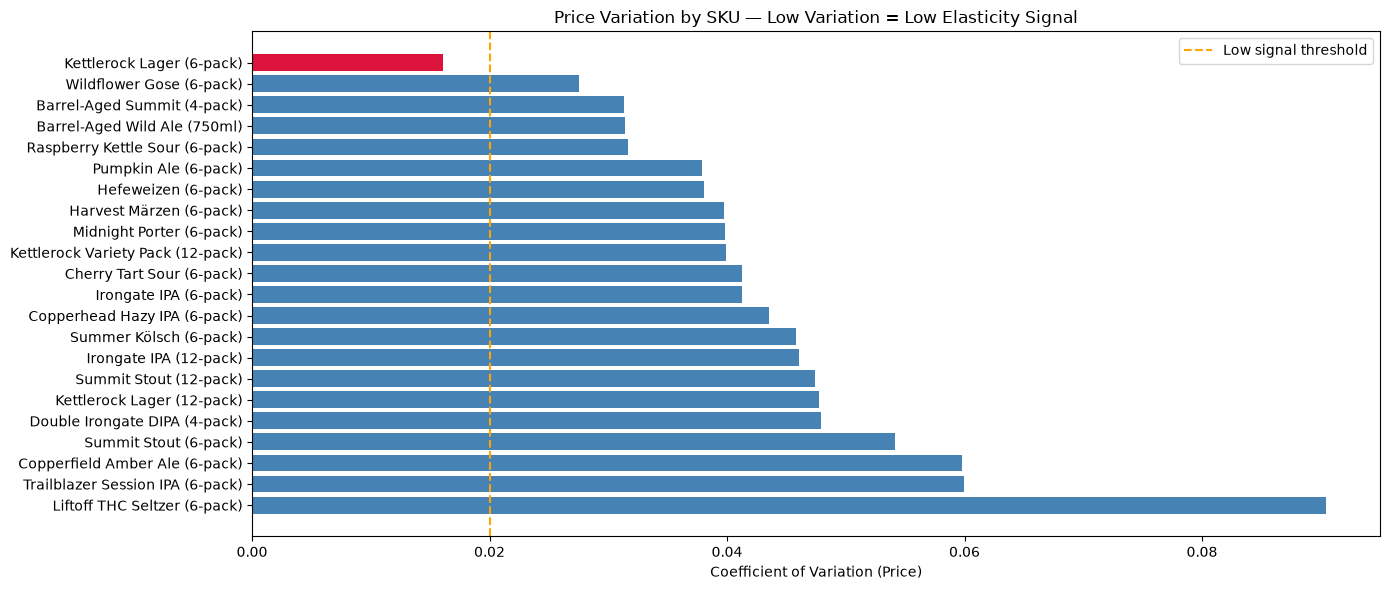

In [13]:
price_var = (
    df.groupby(['sku_id', 'sku_name', 'category', 'pack_size'])['price']
    .agg(std='std', n_unique='nunique', mean='mean')
    .reset_index()
)

price_var['cv']    = price_var['std'] / price_var['mean']
price_var['label'] = price_var['sku_name'] + ' (' + price_var['pack_size'] + ')'
price_var = price_var.sort_values('cv', ascending=False)

colors = ['crimson' if sid == 'SKU010' else 'steelblue'
          for sid in price_var['sku_id']]

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(price_var['label'], price_var['cv'], color=colors)
ax.set_xlabel('Coefficient of Variation (Price)')
ax.set_title('Price Variation by SKU — Low Variation = Low Elasticity Signal')
ax.axvline(0.02, color='orange', linestyle='--', label='Low signal threshold')
ax.legend()
plt.tight_layout()
plt.show()

Normalizing standard deviation by price, we can see the SKUs that don't vary much by price over time and those that do. Kettlerock Lager 6-pack has a very low coefficient of variation, so we should keep and eye on that one while modeling.

### Part 2 -> Log-log linearity check
The entire model assumes log(units) ~ log(price) is linear. You should actually verify this rather than assume it. Scatter plot of log(price) vs log(units_sold) for 3-4 key SKUs, one per category. If it looks roughly linear, great — proceed. If it curves, that's your GAM motivation right there.

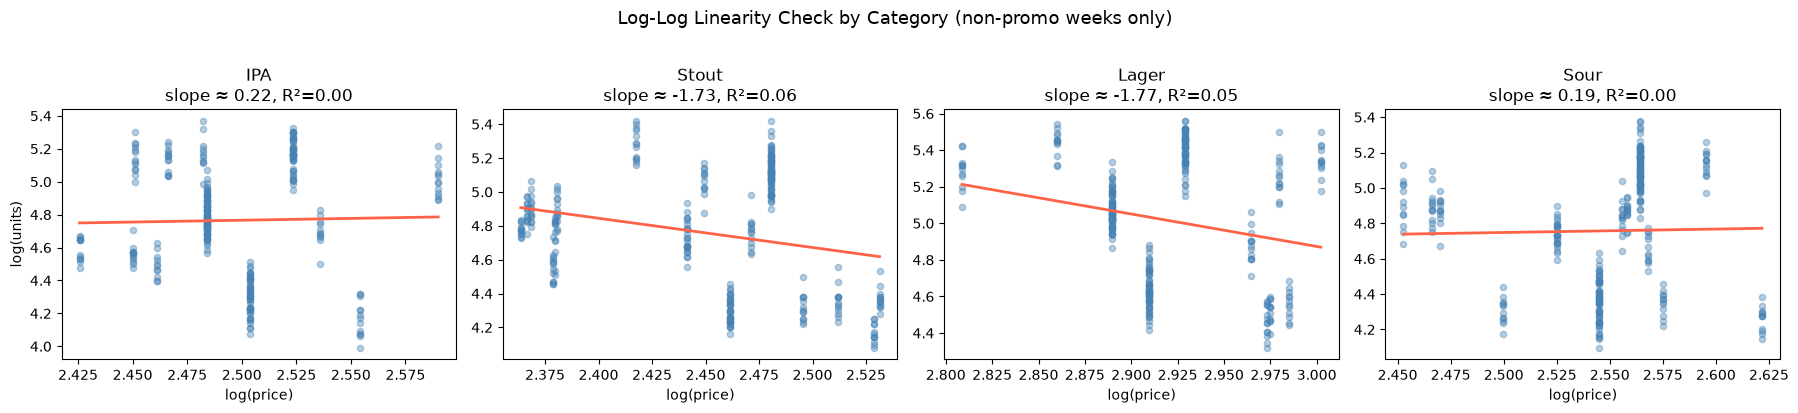

In [14]:
# Pick one representative SKU per category
spotlight_skus = {
    'IPA':   'SKU001',
    'Stout': 'SKU006',
    'Lager': 'SKU011',
    'Sour':  'SKU016',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (cat, sku_id) in zip(axes, spotlight_skus.items()):
    sub = df[(df.sku_id == sku_id) & (~df.is_promo)].copy()
    sub['log_price'] = np.log(sub['price'])
    sub['log_units'] = np.log(sub['units_sold'])

    ax.scatter(sub['log_price'], sub['log_units'],
               alpha=0.4, color='steelblue', s=20)

    # OLS trend line
    slope, intercept, r, *_ = stats.linregress(sub['log_price'], sub['log_units'])
    x_range = np.linspace(sub['log_price'].min(), sub['log_price'].max(), 100)
    ax.plot(x_range, intercept + slope * x_range, color='tomato', linewidth=2)

    ax.set_title(f'{cat}\nslope ≈ {slope:.2f}, R²={r**2:.2f}')
    ax.set_xlabel('log(price)')
    ax.set_ylabel('log(units)' if cat == 'IPA' else '')

plt.suptitle('Log-Log Linearity Check by Category (non-promo weeks only)', 
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

- Slope should be negative, meaning price increases lead to lower demand, except the amber ale & thc which are built to be wacky.
- R2 measures how much price directly influences demand, high R2 means price is perhaps correlated with the trend, low R2 means there are several other factors that influence demand other than price
- We just eyeball this one to see if the relationship is linear or if we think there is some other type of relationship here.

### Part 3 -> Price-season collinearity
The single biggest confounder in the dataset. If prices tend to rise in summer when demand is naturally high, naive OLS will underestimate true elasticity. Run a simple correlation between price and week_of_year per SKU and show a heatmap or bar chart. This is the "why we need controls" slide.

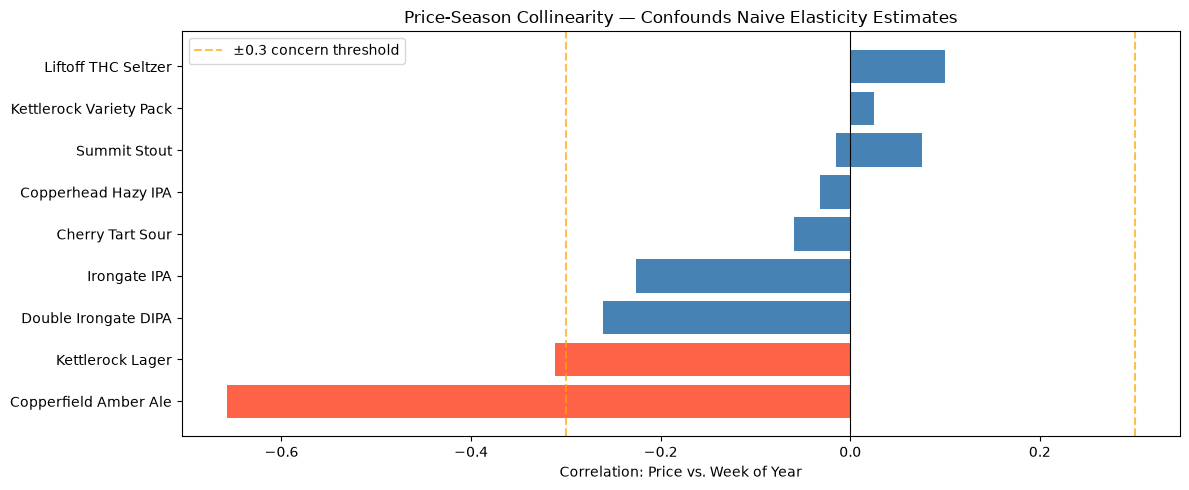

In [15]:
# Correlation between price and week_of_year per SKU (year-round SKUs only)
yr_skus = df[df.is_seasonal_release == False]

corr = (
    yr_skus.groupby(['sku_id', 'sku_name'])
    .apply(lambda g: g['price'].corr(g['week_of_year']))
    .reset_index(name='price_season_corr')
    .sort_values('price_season_corr')
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tomato' if abs(c) > 0.3 else 'steelblue' 
          for c in corr['price_season_corr']]
ax.barh(corr['sku_name'], corr['price_season_corr'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='orange', linestyle='--', alpha=0.7, label='±0.3 concern threshold')
ax.axvline(-0.3, color='orange', linestyle='--', alpha=0.7)
ax.set_xlabel('Correlation: Price vs. Week of Year')
ax.set_title('Price-Season Collinearity — Confounds Naive Elasticity Estimates')
ax.legend()
plt.tight_layout()
plt.show()

We are seeing some heavy correlation with certain product's price and the weeks per year, so price changes by season.

### Part 4 -> Promo contamination
Show what happens to elasticity estimates if you ignore promos. Quick version: compute naive point elasticity (% change in volume / % change in price) on all weeks, then split promo vs. non-promo. Promo weeks will show inflated demand response that has nothing to do with price sensitivity. This directly justifies the is_promo flag as a covariate.

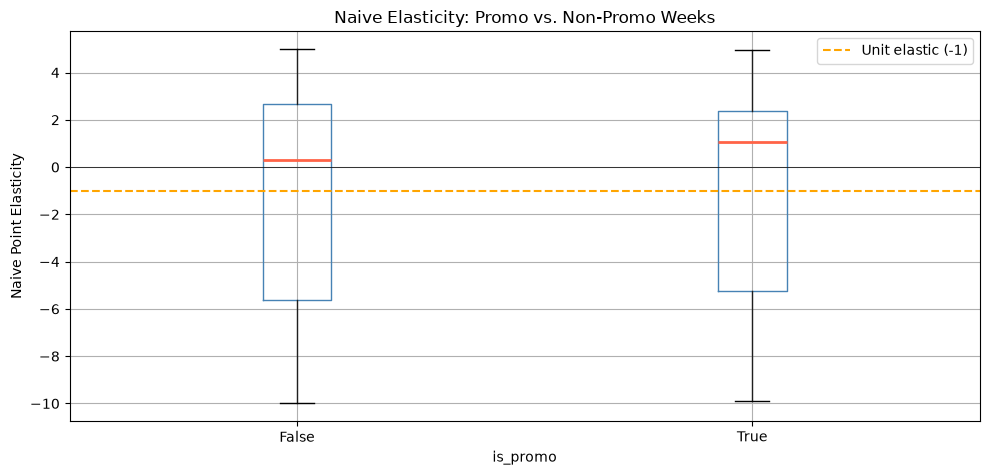

           count  mean   std   min   25%   50%   75%   max
is_promo                                                  
False     1128.0 -1.38  4.61 -9.99 -5.61  0.31  2.66  4.99
True        80.0 -0.93  4.52 -9.88 -5.25  1.06  2.36  4.96


In [16]:
# Naive point elasticity: % change in units / % change in price, week over week
sku_dfs = []
for sku_id, grp in df.groupby('sku_id'):
    grp = grp.sort_values('week').copy()
    grp['price_pct_chg'] = grp['price'].pct_change()
    grp['units_pct_chg'] = grp['units_sold'].pct_change()
    sku_dfs.append(grp)

event_df = pd.concat(sku_dfs)

# Keep only weeks where price actually changed
events = event_df[
    (event_df['price_pct_chg'].abs() > 0.01) &
    (event_df['price_pct_chg'].abs() < 0.30)   # drop extreme outliers
].copy()

events['naive_elasticity'] = events['units_pct_chg'] / events['price_pct_chg']
events = events[events['naive_elasticity'].between(-10, 5)]  # clip extremes

fig, ax = plt.subplots(figsize=(10, 5))
events.boxplot(column='naive_elasticity', by='is_promo', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
ax.axhline(-1, color='orange', linestyle='--', label='Unit elastic (-1)')
ax.axhline(0,  color='black',  linewidth=0.5)
ax.set_title('Naive Elasticity: Promo vs. Non-Promo Weeks')
ax.set_xlabel('is_promo')
ax.set_ylabel('Naive Point Elasticity')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print(events.groupby('is_promo')['naive_elasticity'].describe().round(2))

Price Elasticity is different when there is a promo vs when there is no promo

### Part 5 -> Instrument relevance (Hawkstone)
For Double ML you need to show the instrument is relevant. Plot Kettlerock IPA price vs. Hawkstone IPA price over time. They should move in the same direction but not perfectly. Then show the actual correlation coefficient — you want something like 0.5-0.75, strong enough to be a useful instrument but not so tight that it's suspicious.

Hawkstone–Kettlerock price correlation by category:
  IPA: r = 0.138
  Lager: r = 0.111
  Stout: r = 0.073
  IPA       r = 0.771  F = 149.2
  Lager     r = 0.618  F = 63.1
  Stout     r = 0.860  F = 290.1


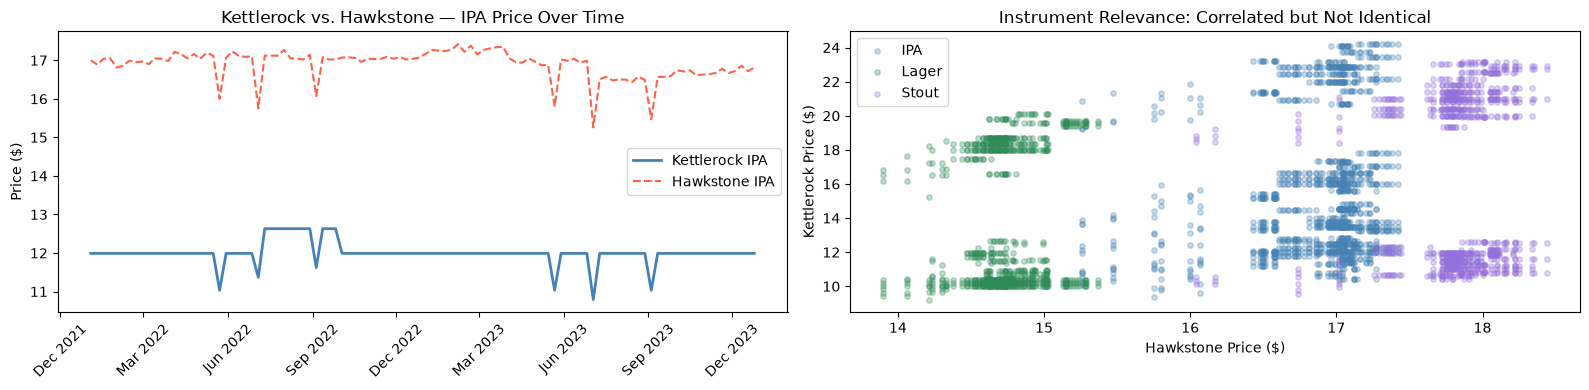

In [27]:
hawk_df = df[df['hawkstone_price'].notna()].copy()

# Time series overlay — IPA in Twin Cities
ipa_tc = hawk_df[(hawk_df.sku_id == 'SKU001') & (hawk_df.region == 'Twin Cities')]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Panel 1: time series
axes[0].plot(ipa_tc['week'], ipa_tc['price'], 
             label='Kettlerock IPA', color='steelblue', linewidth=2)
axes[0].plot(ipa_tc['week'], ipa_tc['hawkstone_price'], 
             label='Hawkstone IPA', color='tomato', linestyle='--', linewidth=1.5)
axes[0].set_title('Kettlerock vs. Hawkstone — IPA Price Over Time')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Panel 2: scatter with correlation
for cat, color in [('IPA','steelblue'), ('Lager','seagreen'), ('Stout','mediumpurple')]:
    sub = hawk_df[hawk_df.category == cat]
    axes[1].scatter(sub['hawkstone_price'], sub['price'],
                    alpha=0.3, label=cat, color=color, s=15)

axes[1].set_xlabel('Hawkstone Price ($)')
axes[1].set_ylabel('Kettlerock Price ($)')
axes[1].set_title('Instrument Relevance: Correlated but Not Identical')
axes[1].legend()

# Print correlations
print("Hawkstone–Kettlerock price correlation by category:")
for cat in ['IPA', 'Lager', 'Stout']:
    sub = hawk_df[hawk_df.category == cat]
    r = sub['price'].corr(sub['hawkstone_price'])
    print(f"  {cat}: r = {r:.3f}")

# Category-week level — correct check
for cat in ['IPA', 'Lager', 'Stout']:
    sub = df[df.category==cat].groupby('week').agg(
        kr=('price', 'mean'), hawk=('hawkstone_price', 'first')
    )
    r = sub['kr'].corr(sub['hawk'])
    n = len(sub)
    print(f"  {cat:8s}  r = {r:.3f}  F = {r**2*(n-2)/(1-r**2):.1f}")

plt.tight_layout()
plt.show()

Hawkstone price correlatation isn't super high, not as high as I thought it would be. 

### Part 6 -> Naive point elasticity baseline by category
Calculate the back-of-napkin elasticity at every observed price change event and plot it by category. This is your pre-model baseline — the number a product manager would compute on a whiteboard. Showing it's noisy and inconsistent is the whole justification for building something more rigorous. It also sets up the model comparison story cleanly.

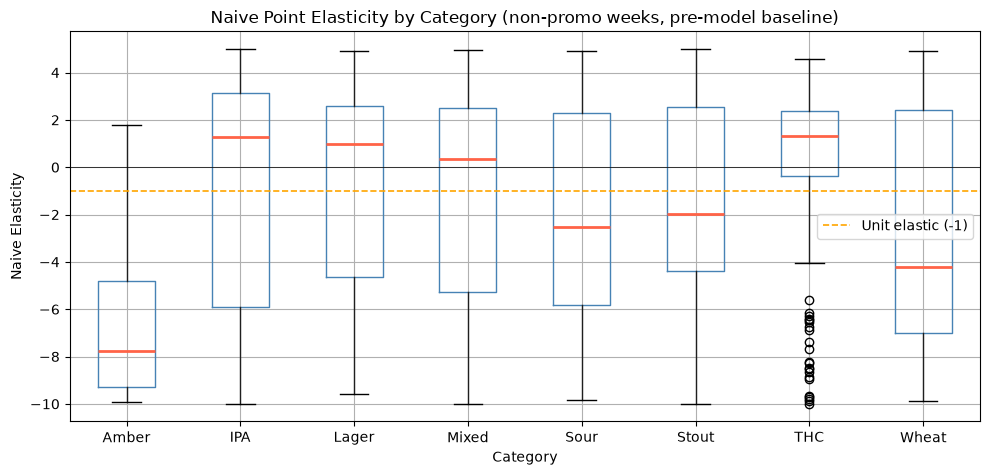


Baseline naive elasticity summary by category:
          median   std  count
category                     
Amber      -7.75  3.42     38
IPA         1.28  4.79    363
Lager       0.97  4.41    107
Mixed       0.33  4.27     69
Sour       -2.52  4.49    136
Stout      -1.98  4.33    249
THC         1.32  4.03    117
Wheat      -4.21  5.31     49


In [18]:
# Use non-promo events only for the clean baseline
baseline = events[events['is_promo'] == False].copy()

fig, ax = plt.subplots(figsize=(10, 5))

category_order = baseline.groupby('category')['naive_elasticity'].median().sort_values().index
colors_cat = {'IPA':'steelblue','Stout':'mediumpurple',
              'Lager':'seagreen','Sour':'tomato',
              'Wheat':'goldenrod','Mixed':'gray'}

baseline.boxplot(column='naive_elasticity', by='category',
                 ax=ax, #order=category_order,
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='tomato', linewidth=2),
                 patch_artist=False)

ax.axhline(-1, color='orange', linestyle='--', linewidth=1.2, label='Unit elastic (-1)')
ax.axhline(0,  color='black', linewidth=0.5)
ax.set_title('Naive Point Elasticity by Category (non-promo weeks, pre-model baseline)')
ax.set_xlabel('Category')
ax.set_ylabel('Naive Elasticity')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nBaseline naive elasticity summary by category:")
print(baseline.groupby('category')['naive_elasticity']
      .agg(['median','std','count']).round(2))

***
### **Notes**:

***

## Model Training

In [19]:
df.to_csv('../data/kettlerock_sales_4.csv', index=False)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Load & filter ─────────────────────────────────────────────────────────────
df = pd.read_csv('../data/kettlerock_sales_4.csv', parse_dates=['week'])
# model_df = df[df.sku_id != 'SKU010'].copy()   # drop flat-price SKU — no signal
model_df = df.copy()

# ── Log transforms ────────────────────────────────────────────────────────────
model_df['log_price'] = np.log(model_df['price'])
model_df['log_units'] = np.log(model_df['units_sold'])

# ── Trend variable (weeks since data start) ───────────────────────────────────
min_week = model_df['week'].min()
model_df['trend'] = ((model_df['week'] - min_week).dt.days / 7).astype(float)

# ── Entity ID for panel models (SKU × Region) ─────────────────────────────────
model_df['entity'] = model_df['sku_id'] + '_' + model_df['region']

# ── Category list for reference ───────────────────────────────────────────────
categories = sorted(model_df['category'].unique())
print(f"Rows: {len(model_df)} | SKUs: {model_df.sku_id.nunique()} | Categories: {categories}")

Rows: 4848 | SKUs: 22 | Categories: ['Amber', 'IPA', 'Lager', 'Mixed', 'Sour', 'Stout', 'THC', 'Wheat']


### Model 1 -> Log-Log OLS No Controls

In [21]:
# The naive baseline model. Pooled across all SKUs.
# Tells us the average elasticity before controlling for anything.

m1 = smf.ols('log_units ~ log_price', data=model_df).fit()
e_m1 = m1.params['log_price']

print(f"Model 1 — OLS (no controls)")
print(f"  Pooled elasticity: {e_m1:.3f}  (p={m1.pvalues['log_price']:.4f})")
print(f"  R²: {m1.rsquared:.3f}")
print(f"\n  Expect this to be biased — no seasonal or promo controls.")

Model 1 — OLS (no controls)
  Pooled elasticity: 0.072  (p=0.0091)
  R²: 0.001

  Expect this to be biased — no seasonal or promo controls.


### Model 2 -> Log-Log OLS with Controls + Category Elasticities

In [22]:
# Adds season, promo, region, and trend controls.
# Category interaction with log_price gives us separate elasticity per category.

formula = (
    'log_units ~ log_price * C(category)'
    ' + C(season) + is_promo + C(region) + trend'
)

m2 = smf.ols(formula, data=model_df).fit()

# ── Extract category-level elasticities ───────────────────────────────────────
base_cat  = sorted(model_df['category'].unique())[0]   # statsmodels drops first alphabetically
base_coef = m2.params['log_price']

cat_elasticities_m2 = {}
for cat in categories:
    key = f'log_price:C(category)[T.{cat}]'
    adj = m2.params.get(key, 0.0)
    cat_elasticities_m2[cat] = base_coef + adj

print("Model 2 — OLS with Controls")
print(f"  R²: {m2.rsquared:.3f}")
for cat, e in cat_elasticities_m2.items():
    print(f"  {cat:10s}: {e:.3f}")

Model 2 — OLS with Controls
  R²: 0.625
  Amber     : 0.392
  IPA       : 0.076
  Lager     : 0.288
  Mixed     : -0.977
  Sour      : -1.572
  Stout     : 0.003
  THC       : 2.931
  Wheat     : 1.260


### Model 3 -> Fixed Effects Panel (SKU x Region entities)

In [23]:
# pip install linearmodels
from linearmodels.panel import PanelOLS

# ── Panel setup ───────────────────────────────────────────────────────────────
panel = (
    model_df
    .set_index(['entity', 'week'])
    .sort_index()
)

# Entity (SKU×Region) fixed effects absorb all time-invariant SKU characteristics.
# Identifying variation: how price changes WITHIN each SKU×Region over time.

fe_model = PanelOLS(
    dependent=panel['log_units'],
    exog=panel[['log_price', 'is_promo', 'trend']],
    entity_effects=True,
    time_effects=False,
)
fe_result = fe_model.fit(cov_type='clustered', cluster_entity=True)

e_fe = fe_result.params['log_price']
print("Model 3 — Fixed Effects Panel")
print(f"  Pooled elasticity: {e_fe:.3f}  (p={fe_result.pvalues['log_price']:.4f})")
print(f"  R² (within): {fe_result.rsquared:.3f}")
print(f"\n  Note: FE controls for SKU-level unobservables (brand loyalty, quality tier)")
print(fe_result.summary.tables[1])

Model 3 — Fixed Effects Panel
  Pooled elasticity: 0.427  (p=0.4355)
  R² (within): 0.034

  Note: FE controls for SKU-level unobservables (brand loyalty, quality tier)
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
log_price      0.4269     0.5474     0.7798     0.4355     -0.6463      1.5001
is_promo       0.1724     0.0490     3.5156     0.0004      0.0763      0.2685
trend          0.0005     0.0006     0.8592     0.3903     -0.0007      0.0018


### Model 4 -> GAM (non-constant elasticity)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Model 4 — GAM
  Avg pooled elasticity: 0.731
  Pseudo-R²: 0.545
  Amber     : 2.881
  IPA       : 0.373
  Lager     : 2.658
  Mixed     : 0.835
  Sour      : -2.901
  Stout     : 0.737
  THC       : 3.091
  Wheat     : 0.558


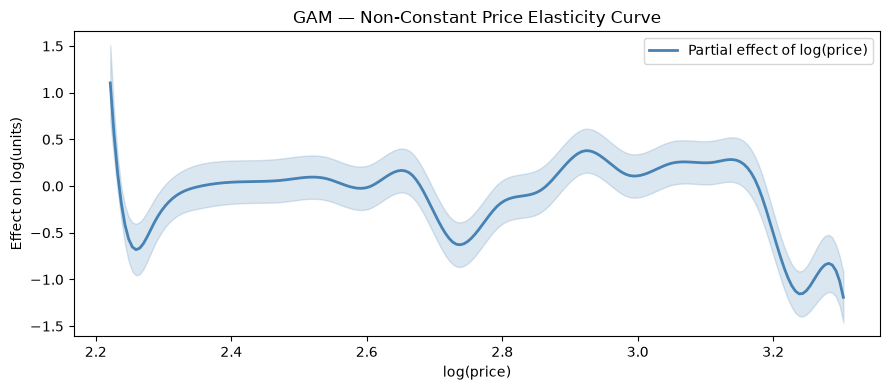

In [24]:
# pip install pygam
from pygam import LinearGAM, s, l, f

# ── Feature matrix ────────────────────────────────────────────────────────────
region_codes  = pd.Categorical(model_df['region']).codes
season_codes  = pd.Categorical(model_df['season']).codes
category_codes = pd.Categorical(model_df['category']).codes

X_gam = np.column_stack([
    model_df['log_price'].values,   # 0 — smooth term (elasticity curve)
    model_df['week_of_year'].values, # 1 — smooth term (seasonality)
    region_codes,                    # 2 — factor
    season_codes,                    # 3 — factor
    model_df['is_promo'].values,     # 4 — linear
    model_df['trend'].values,        # 5 — linear
])
y_gam = model_df['log_units'].values

gam = LinearGAM(s(0) + s(1) + f(2) + f(3) + l(4) + l(5))
gam.gridsearch(X_gam, y_gam)        # auto-tune smoothing lambda

# ── Average elasticity: numerical derivative of smooth term ───────────────────
X_base     = X_gam.copy()
X_shifted  = X_gam.copy()
X_shifted[:, 0] += 0.01             # nudge log_price by 0.01

pred_base    = gam.predict(X_base)
pred_shifted = gam.predict(X_shifted)

e_gam_avg = np.mean((pred_shifted - pred_base) / 0.01)

# ── Category-level average elasticity ────────────────────────────────────────
cat_elasticities_gam = {}
for cat in categories:
    mask = model_df['category'] == cat
    cat_elasticities_gam[cat] = np.mean(
        (pred_shifted[mask] - pred_base[mask]) / 0.01
    )

print("Model 4 — GAM")
print(f"  Avg pooled elasticity: {e_gam_avg:.3f}")
print(f"  Pseudo-R²: {gam.statistics_['pseudo_r2']['explained_deviance']:.3f}")
for cat, e in cat_elasticities_gam.items():
    print(f"  {cat:10s}: {e:.3f}")

# ── Visualize the demand curve shape ─────────────────────────────────────────
XX = gam.generate_X_grid(term=0, n=200)
pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(XX[:, 0], pdep, color='steelblue', linewidth=2, label='Partial effect of log(price)')
ax.fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.2, color='steelblue')
ax.set_xlabel('log(price)')
ax.set_ylabel('Effect on log(units)')
ax.set_title('GAM — Non-Constant Price Elasticity Curve')
ax.legend()
plt.tight_layout()
plt.show()

### Model 5 -> Double ML

In [25]:
# pip install econml
from econml.dml import LinearDML
from sklearn.ensemble import GradientBoostingRegressor

# ── Feature setup ─────────────────────────────────────────────────────────────
# Y = log_units (outcome)
# T = log_price (treatment)
# X = everything we want to partial out (confounders)

X_dml = pd.get_dummies(
    model_df[['season', 'region']],
    drop_first=True
).astype(float)
X_dml['is_promo']     = model_df['is_promo'].astype(float)
X_dml['trend']        = model_df['trend']
X_dml['week_of_year'] = model_df['week_of_year'].astype(float)

Y   = model_df['log_units'].values
T   = model_df['log_price'].values
X   = X_dml.values

# ── Pooled Double ML ──────────────────────────────────────────────────────────
# GBM models for Y~X and T~X nuisance estimation, then OLS on residuals
dml = LinearDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    discrete_treatment=False,
    cv=4,
    random_state=42
)
dml.fit(Y, T, X=X)

e_dml_pooled = dml.coef_[0]
e_dml_ci     = dml.coef__interval(alpha=0.05)
print(f"Model 5 — Double ML (pooled)")
print(f"  Elasticity: {e_dml_pooled:.3f}  95% CI: [{e_dml_ci[0][0]:.3f}, {e_dml_ci[1][0]:.3f}]")

# ── Category-level Double ML (loop) ──────────────────────────────────────────
cat_elasticities_dml = {}
for cat in categories:
    mask  = model_df['category'] == cat
    if mask.sum() < 50:
        continue
    dml_c = LinearDML(
        model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
        model_t=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
        discrete_treatment=False,
        cv=4,
        random_state=42
    )
    dml_c.fit(Y[mask], T[mask], X=X[mask])
    cat_elasticities_dml[cat] = dml_c.coef_[0]
    print(f"  {cat:10s}: {dml_c.coef_[0]:.3f}")

Model 5 — Double ML (pooled)
  Elasticity: 0.440  95% CI: [0.103, 0.777]
  Amber     : -81.995
  IPA       : -0.240
  Lager     : 0.021
  Mixed     : -2.959
  Sour      : 1.021
  Stout     : 0.345
  THC       : 350.379
  Wheat     : -1.171


### Model 6 -> Hierarchical Bayesian - PyMC

In [ ]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az

# ── Index encodings ───────────────────────────────────────────────────────────
sku_list    = model_df['sku_id'].unique().tolist()
cat_list    = sorted(model_df['category'].unique().tolist())
region_list = sorted(model_df['region'].unique().tolist())
season_list = sorted(model_df['season'].unique().tolist())

sku2idx    = {s: i for i, s in enumerate(sku_list)}
cat2idx    = {c: i for i, c in enumerate(cat_list)}
region2idx = {r: i for i, r in enumerate(region_list)}
season2idx = {s: i for i, s in enumerate(season_list)}

# Which category does each SKU belong to?
sku_cat_idx = np.array([
    cat2idx[model_df[model_df.sku_id == s]['category'].iloc[0]]
    for s in sku_list
])

sku_idx    = model_df['sku_id'].map(sku2idx).values
region_idx = model_df['region'].map(region2idx).values
season_idx = model_df['season'].map(season2idx).values

log_price_arr = model_df['log_price'].values.astype(float)
log_units_arr = model_df['log_units'].values.astype(float)
is_promo_arr  = model_df['is_promo'].astype(float).values
trend_arr     = model_df['trend'].values.astype(float)

n_skus    = len(sku_list)
n_cats    = len(cat_list)
n_regions = len(region_list)
n_seasons = len(season_list)

# ── Model ─────────────────────────────────────────────────────────────────────
with pm.Model() as hb_model:

    # ── Category-level elasticity hyperpriors ─────────────────────────────────
    # Prior: elasticities are negative, likely between -0.5 and -3.0
    mu_cat    = pm.Normal('mu_cat',    mu=-1.5, sigma=0.5,  shape=n_cats)
    sigma_cat = pm.HalfNormal('sigma_cat', sigma=0.4, shape=n_cats)

    # ── SKU elasticities (non-centered parameterization) ──────────────────────
    # Non-centered avoids funnel geometry and speeds up sampling
    z_sku = pm.Normal('z_sku', mu=0, sigma=1, shape=n_skus)
    beta  = pm.Deterministic(
        'beta',
        mu_cat[sku_cat_idx] + sigma_cat[sku_cat_idx] * z_sku
    )

    # ── SKU-level intercepts ──────────────────────────────────────────────────
    alpha = pm.Normal('alpha', mu=4.5, sigma=1.0, shape=n_skus)

    # ── Promo effect (positive — promos lift volume) ──────────────────────────
    gamma_promo = pm.Normal('gamma_promo', mu=0.15, sigma=0.2)

    # ── Region effects ────────────────────────────────────────────────────────
    gamma_region = pm.Normal('gamma_region', mu=0, sigma=0.3, shape=n_regions)

    # ── Season effects ────────────────────────────────────────────────────────
    gamma_season = pm.Normal('gamma_season', mu=0, sigma=0.3, shape=n_seasons)

    # ── Global trend (handles THC rise + Amber decline at population level) ───
    # Note: a production model would give each SKU its own trend coefficient
    gamma_trend = pm.Normal('gamma_trend', mu=0, sigma=0.02)

    # ── Expected log demand ───────────────────────────────────────────────────
    mu = (
        alpha[sku_idx]
        + beta[sku_idx] * log_price_arr
        + gamma_promo   * is_promo_arr
        + gamma_region[region_idx]
        + gamma_season[season_idx]
        + gamma_trend   * trend_arr
    )

    # ── Observation noise ─────────────────────────────────────────────────────
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=0.2)
    pm.Normal('log_units_obs', mu=mu, sigma=sigma_obs, observed=log_units_arr)

    # ── Sample ────────────────────────────────────────────────────────────────
    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.90,
        random_seed=42,
        progressbar=True,
    )

# ── Extract results ───────────────────────────────────────────────────────────
# Category-level elasticity: posterior mean of mu_cat per category
cat_elasticities_hb = {}
for i, cat in enumerate(cat_list):
    post = trace.posterior['mu_cat'].values[:, :, i].flatten()
    cat_elasticities_hb[cat] = {
        'mean':  post.mean(),
        'hdi_lo': np.percentile(post, 2.5),
        'hdi_hi': np.percentile(post, 97.5),
    }

print("\nModel 6 — Hierarchical Bayes")
print(f"  {'Category':10s}  {'Mean':>6s}  {'95% HDI':>16s}")
for cat, vals in cat_elasticities_hb.items():
    print(f"  {cat:10s}  {vals['mean']:>6.3f}  [{vals['hdi_lo']:>6.3f}, {vals['hdi_hi']:>6.3f}]")

# ── Convergence check ─────────────────────────────────────────────────────────
print("\nR-hat check (should be < 1.01):")
rhats = az.rhat(trace)
print(f"  mu_cat max R-hat:  {float(rhats['mu_cat'].max()):.4f}")
print(f"  beta max R-hat:    {float(rhats['beta'].max()):.4f}")

In [22]:
import arviz as az
import pandas as pd
import numpy as np

# Full trace — for posterior predictive checks, R-hat, etc. (stays in conda)
az.to_netcdf(trace, '../model/kettlerock_hb_trace.nc')

# Summary CSV — for cross-model comparison in venv
hb_rows = []
for i, cat in enumerate(cat_list):
    post = trace.posterior['mu_cat'].values[:, :, i].flatten()
    hb_rows.append({
        'category':  cat,
        'hb_mean':   post.mean(),
        'hb_median': np.median(post),
        'hb_hdi_lo': np.percentile(post, 2.5),
        'hb_hdi_hi': np.percentile(post, 97.5),
        'hb_std':    post.std(),
    })

pd.DataFrame(hb_rows).to_csv('../model/hb_elasticities.csv', index=False)
print("saved.")

saved.


***
### **Notes**:

***

## Model Validation

### Validation 1 -> Quick Model Comparison

In [26]:
# ── Collect category-level elasticities across all models ─────────────────────
hb = pd.read_csv('../model/hb_elasticities.csv')

results = pd.DataFrame({'category': categories})
results['OLS_nocontrols'] = e_m1
results['OLS_controls']   = results['category'].map(cat_elasticities_m2)
results['Fixed_Effects']  = e_fe
results['GAM']            = results['category'].map(cat_elasticities_gam)
results['Double_ML']      = results['category'].map(cat_elasticities_dml)
results = results.merge(hb[['category','hb_mean','hb_hdi_lo','hb_hdi_hi']], 
                        on='category', how='left')

print("\n── Price Elasticity Estimates by Category and Model ──")
print(results.set_index('category').round(3).to_string())


── Price Elasticity Estimates by Category and Model ──
          OLS_nocontrols  OLS_controls  Fixed_Effects    GAM  Double_ML  hb_mean  hb_hdi_lo  hb_hdi_hi
category                                                                                              
Amber              0.072         0.392          0.427  2.881    -81.995   -0.727     -1.770      0.134
IPA                0.072         0.076          0.427  0.373     -0.240   -0.761     -1.027     -0.514
Lager              0.072         0.288          0.427  2.658      0.021   -0.751     -1.276     -0.338
Mixed              0.072        -0.977          0.427  0.835     -2.959   -0.917     -1.728     -0.307
Sour               0.072        -1.572          0.427 -2.901      1.021   -0.395     -0.906     -0.015
Stout              0.072         0.003          0.427  0.737      0.345   -0.497     -0.897     -0.179
THC                0.072         2.931          0.427  3.091    350.379   -0.844     -1.860      0.148
Wheat            

***
### **Notes**:

***

## Insights

In [19]:
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

### Part 1 -> Price variation per SKU (identification check)

***
### **Notes**:

***